## 1. Load & Inspect Data

In [41]:
import pandas as pd
df = pd.read_csv('D:\\bank-churn-prediction\\dataset\\churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.shape

(10000, 14)

In [10]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [14]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

## 2. Exploratory Data Analysis

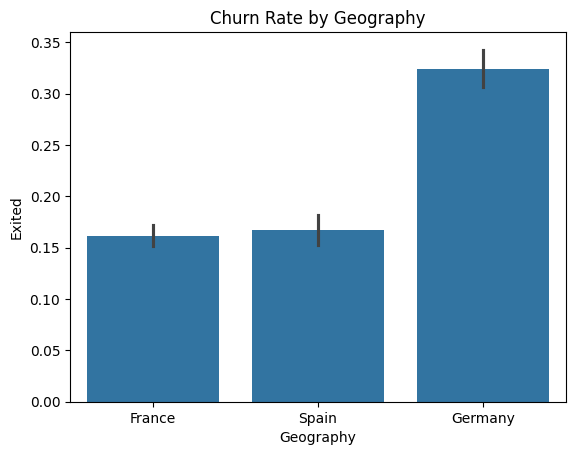

In [42]:
df.groupby('Geography')['Exited'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Geography', y='Exited', data=df)
plt.title('Churn Rate by Geography')
plt.show()

Germany churns at ~32%, roughly double France (~16%) and Spain (~17%). Verified this isn't a small-sample artifact — Germany and Spain have nearly identical customer counts.

In [43]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [44]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [18]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

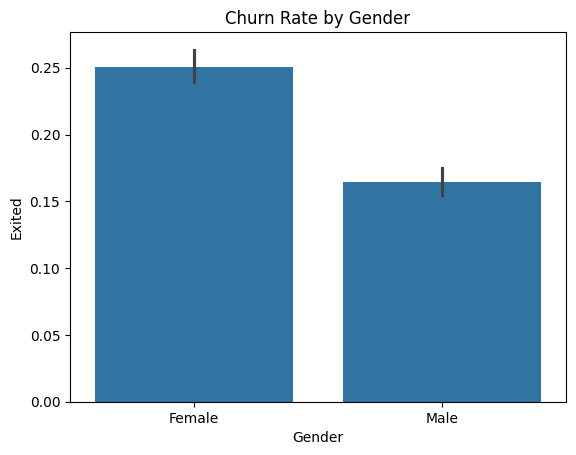

In [45]:
df.groupby('Gender')['Exited'].mean()

sns.barplot(x='Gender', y='Exited', data=df)
plt.title('Churn Rate by Gender')
plt.show()

Female customers churn more (~25%) than male customers (~16%).

C:\Users\Ruffina\AppData\Local\Temp\ipykernel_26540\1536484744.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Exited'].mean()


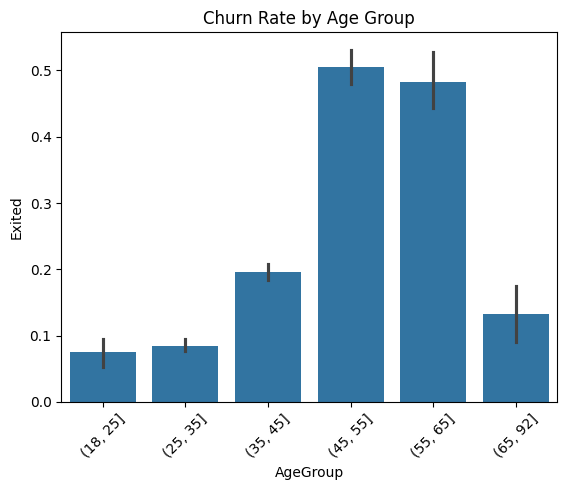

In [46]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65, 92])
df.groupby('AgeGroup')['Exited'].mean()

sns.barplot(x='AgeGroup', y='Exited', data=df)
plt.title('Churn Rate by Age Group')
plt.xticks(rotation=45)
plt.show()

Churn rises sharply through middle age, peaking around 45–65 (~50%), then drops for older customers. Raw per-year plotting was too noisy due to very few customers at extreme ages — binning revealed the real trend.

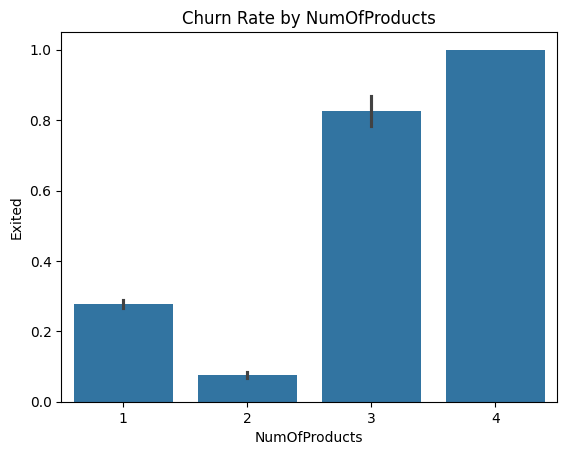

In [47]:
df.groupby('NumOfProducts')['Exited'].mean()

sns.barplot(x='NumOfProducts', y='Exited', data=df)
plt.title('Churn Rate by NumOfProducts')
plt.show()

In [48]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

A U-shaped pattern — 2 products churns least (~8%), while 1 product (~28%) and 3+ products churn more. The 3-4 product groups are based on small samples (266 and 60 customers) and should be treated as suggestive, not conclusive.

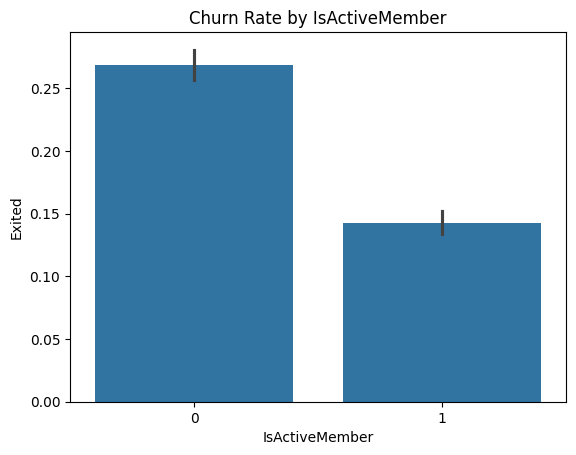

In [49]:
df.groupby('IsActiveMember')['Exited'].mean()

sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title('Churn Rate by IsActiveMember')
plt.show()

Inactive members churn roughly twice as often (~27%) as active members (~14%).

C:\Users\Ruffina\AppData\Local\Temp\ipykernel_26540\2707850262.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('BalanceGroup')['Exited'].mean()


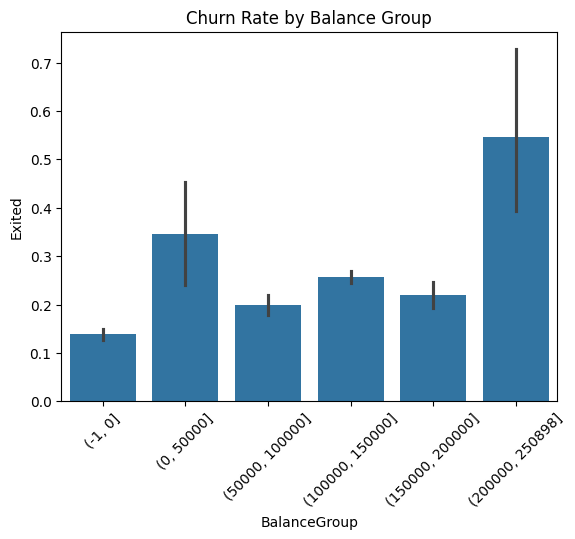

In [50]:
df['BalanceGroup'] = pd.cut(df['Balance'], bins=[-1, 0, 50000, 100000, 150000, 200000, 250898])
df.groupby('BalanceGroup')['Exited'].mean()

sns.barplot(x='BalanceGroup', y='Exited', data=df)
plt.title('Churn Rate by Balance Group')
plt.xticks(rotation=45)
plt.show()

In [51]:
df['BalanceGroup'].value_counts()

BalanceGroup
(100000, 150000]    3830
(-1, 0]             3617
(50000, 100000]     1509
(150000, 200000]     935
(0, 50000]            75
(200000, 250898]      33
Name: count, dtype: int64

Zero-balance customers churn least (~14%); fairly flat (~20-26%) across mid-range balances. Spikes at very low/high balance ranges are based on small samples (75 and 33 customers) and are not reliable.

## 3. Preprocessing

In [52]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(35, 45]","(-1, 0]"
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(35, 45]","(50000, 100000]"
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(35, 45]","(150000, 200000]"
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(35, 45]","(-1, 0]"
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(35, 45]","(100000, 150000]"


In [53]:
df = df.drop(['AgeGroup', 'BalanceGroup'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [54]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [55]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model 1 — Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

## 5. Evaluation — Logistic Regression

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7195
Precision: 0.38461538461538464
Recall: 0.712468193384224
[[1159  448]
 [ 113  280]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



## 6. Model 2 — Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8685
Precision: 0.7850877192982456
Recall: 0.455470737913486
[[1558   49]
 [ 214  179]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.79      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## 7. Threshold Tuning

In [60]:
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_adjusted = (y_proba_rf >= 0.3).astype(int)

print("Recall:", recall_score(y_test, y_pred_rf_adjusted))
print("Precision:", precision_score(y_test, y_pred_rf_adjusted))

Recall: 0.6590330788804071
Precision: 0.5642701525054467


## 8. Feature Importance

In [61]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Age                  0.250697
Balance              0.143093
EstimatedSalary      0.138517
NumOfProducts        0.135404
CreditScore          0.131995
Tenure               0.079632
IsActiveMember       0.037793
Geography_Germany    0.028690
Gender_Male          0.021603
HasCrCard            0.018044
Geography_Spain      0.014532
dtype: float64


## 9. Save Model for Deployment

In [62]:
import joblib

joblib.dump(rf_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']